## Bibliotecas

In [1]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic Data

In [2]:
rows = 5000

data = {
    'ndvi': np.random.uniform(0.1, 0.9, rows),
    'soil_moisture': np.random.uniform(5, 60, rows),
    'temperature': np.random.uniform(15, 42, rows),
    'rainfall': np.random.uniform(0, 200, rows),
    'humidity': np.random.uniform(20, 95, rows),
    'wind_speed': np.random.uniform(0, 40, rows),
    'solar_radiation': np.random.uniform(100, 1000, rows),
    'irrigation_hours': np.random.uniform(0, 12, rows),
    'crop_type': np.random.choice(['soy', 'corn', 'cotton'], rows),
    'region': np.random.choice(['north', 'south', 'west'], rows)
}

df_synthetic = pd.DataFrame(data)

conditions = [
    (df_synthetic['soil_moisture'] < 15) & (df_synthetic['temperature'] > 35),
    (df_synthetic['soil_moisture'] < 25)
]

choices = [2, 1]

df_synthetic['stress_risk'] = np.select(
    conditions,
    choices,
    default=0
)

df_synthetic.to_csv(
    '../data/synthetic/synthetic_agro_data.csv',
    index=False
)

df_synthetic.head()

,ndvi,soil_moisture,temperature,rainfall,humidity,wind_speed,solar_radiation,irrigation_hours,crop_type,region,stress_risk
0,0.101370,35.078448,21.434741,128.491502,23.560796,8.837629,115.218309,8.838448,cotton,west,0
1,0.454828,29.365146,36.120840,165.208235,82.908719,3.681462,760.401336,4.159409,corn,west,0
2,0.799309,16.350033,24.423583,151.864751,33.125635,38.958263,313.990694,10.586499,soy,north,1
3,0.772641,13.623483,30.580852,112.228449,67.038559,3.879897,911.293962,0.470506,cotton,west,1
4,0.532484,36.825436,17.720421,128.824081,45.142181,3.710075,848.599804,3.849761,corn,west,0


## Feature Engineering

In [3]:
df = pd.read_csv(
    '../data/synthetic/synthetic_agro_data.csv'
)

df['climate_index'] = (
    df['temperature'] * 0.4 +
    df['humidity'] * 0.2 -
    df['rainfall'] * 0.3
)

df['water_balance'] = (
    df['rainfall'] +
    df['irrigation_hours'] * 10 -
    df['temperature']
)

df.to_csv(
    '../data/processed/final_dataset.csv',
    index=False
)

## Preprocessing

In [4]:
df = pd.read_csv(
    '../data/processed/final_dataset.csv'
)

X = df.drop('stress_risk', axis=1)
y = df['stress_risk']

numeric_features = [
    'ndvi',
    'soil_moisture',
    'temperature',
    'rainfall',
    'humidity',
    'wind_speed',
    'solar_radiation',
    'irrigation_hours'
]

categorical_features = [
    'crop_type',
    'region'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(),
            categorical_features
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Random Forest

In [5]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'classifier',
        RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42
        )
    )
])

rf_pipeline.fit(X_train, y_train)

joblib.dump(
    rf_pipeline,
    '../models/random_forest.pkl'
)

print("Random Forest trained.")

Random Forest trained.


## XGBoost

In [6]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'classifier',
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=8
        )
    )
])

xgb_pipeline.fit(X_train, y_train)

joblib.dump(
    xgb_pipeline,
    '../models/xgboost_model.pkl'
)

print("XGBoost trained.")

XGBoost trained.


## Evaluate

### LOAD MODELS

In [7]:
models = {
    "Random Forest": joblib.load(
        '../models/random_forest.pkl'
    ),

    "XGBoost": joblib.load(
        '../models/xgboost_model.pkl'
    )
}

### RESULTS STORAGE

In [8]:
results = []

### EVALUATION LOOP


MODEL: Random Forest
Accuracy : 0.9990
Precision: 0.9990
Recall   : 0.9990
F1-Score : 0.9990
ROC-AUC  : 1.0000

CONFUSION MATRIX
[[643   0   0]
 [  0 296   0]
 [  0   1  60]]


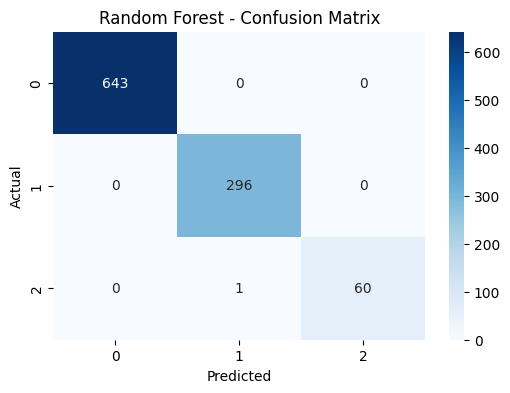


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       643
           1       1.00      1.00      1.00       296
           2       1.00      0.98      0.99        61

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000


MODEL: XGBoost
Accuracy : 0.9970
Precision: 0.9971
Recall   : 0.9970
F1-Score : 0.9970
ROC-AUC  : 1.0000

CONFUSION MATRIX
[[642   1   0]
 [  0 294   2]
 [  0   0  61]]


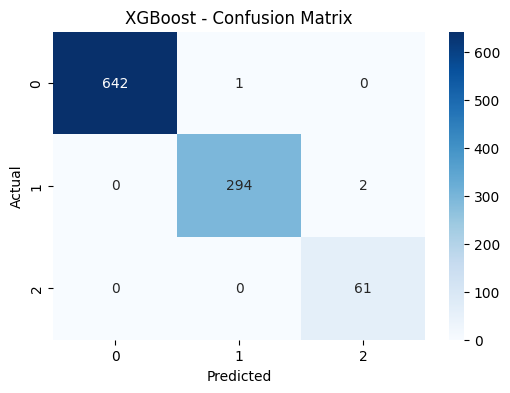


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       643
           1       1.00      0.99      0.99       296
           2       0.97      1.00      0.98        61

    accuracy                           1.00      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000



In [9]:
for name, model in models.items():
    print("\n" + "=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)

    # Predictions
    predictions = model.predict(X_test)

    # Probabilities (ROC-AUC)
    probabilities = model.predict_proba(X_test)

    # Metrics
    # Metrics
    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        predictions,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='weighted'
    )
    roc_auc = roc_auc_score(
        y_test,
        probabilities,
        multi_class='ovr'
    )

    # Save results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    # =========================
    # PRINT METRICS
    # =========================

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    # =========================
    # CONFUSION MATRIX
    # =========================

    cm = confusion_matrix(
        y_test,
        predictions
    )

    print("\nCONFUSION MATRIX")
    print(cm)

    plt.figure(figsize=(6, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # =========================
    # CLASSIFICATION REPORT
    # =========================

    print("\nCLASSIFICATION REPORT")

    print(
        classification_report(
            y_test,
            predictions
        )
    )

    # =========================
    # FEATURE IMPORTANCE
    # =========================

    if hasattr(model, 'feature_importances_'):

        importance = pd.DataFrame({
            'Feature': X_test.columns,
            'Importance': model.feature_importances_
        })

        importance = importance.sort_values(
            by='Importance',
            ascending=False
        )

        print("\nTOP 10 FEATURES")
        print(importance.head(10))

### FINAL COMPARISON

In [10]:
results_df = pd.DataFrame(results)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(results_df)

# Optional: save results
results_df.to_csv(
    '../models/model_comparison.csv',
    index=False
)


MODEL COMPARISON
           Model  Accuracy  Precision  Recall  F1-Score   ROC-AUC
0  Random Forest     0.999   0.999003   0.999  0.998997  1.000000
1        XGBoost     0.997   0.997060   0.997  0.997013  0.999994


# Shap

### Carrega pipeline

In [11]:
model = joblib.load("../models/xgboost_model.pkl")

classifier = model.named_steps["classifier"]
preprocessor = model.named_steps["preprocessor"]

### Pré-processamento

In [12]:
X_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names
)

### SHAP

In [13]:
explainer = shap.Explainer(classifier)

shap_values = explainer(X_processed_df)

### Trata diferentes formatos de saída SHAP


In [14]:
values = shap_values.values

print("Shape SHAP:", values.shape)

# CASO MULTICLASSE -> reduz dimensão da classe
if len(values.shape) == 3:
    # média absoluta entre classes
    importance = np.abs(values).mean(axis=(0, 2))

# CASO BINÁRIO / REGRESSÃO
else:
    importance = np.abs(values).mean(axis=0)

Shape SHAP: (1000, 14, 3)


### Importância global

In [15]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print("\nTop Features:\n")
print(importance_df.head(15))


Top Features:

                  feature  importance
1      num__soil_moisture    3.555068
2        num__temperature    0.915728
9   cat__crop_type_cotton    0.055901
5         num__wind_speed    0.053529
4           num__humidity    0.050858
0               num__ndvi    0.033771
7   num__irrigation_hours    0.030273
3           num__rainfall    0.030244
6    num__solar_radiation    0.017125
11      cat__region_north    0.002161
12      cat__region_south    0.000602
8     cat__crop_type_corn    0.000359
10     cat__crop_type_soy    0.000000
13       cat__region_west    0.000000


### Summary Plot

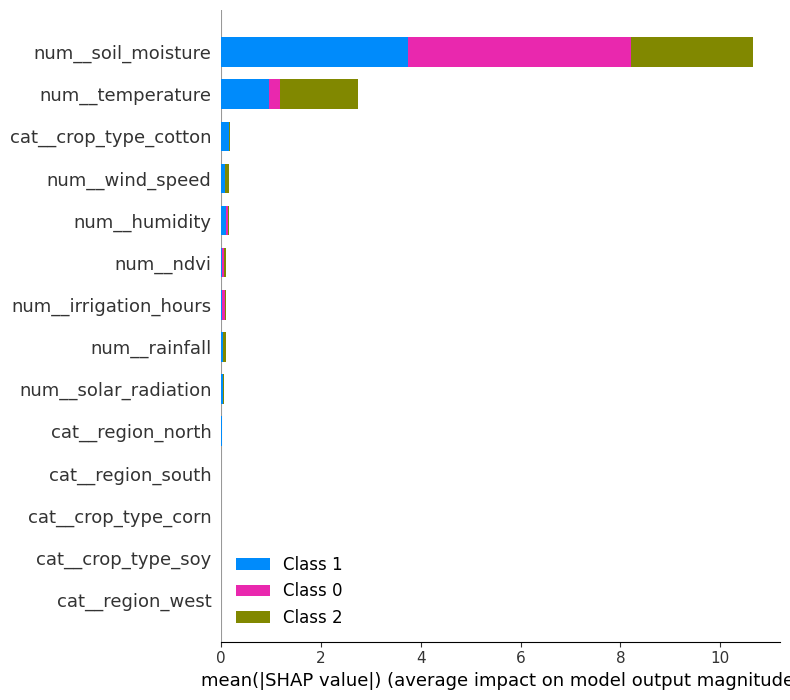

In [16]:
shap.summary_plot(
    shap_values,
    X_processed_df
)

### Bar Plot

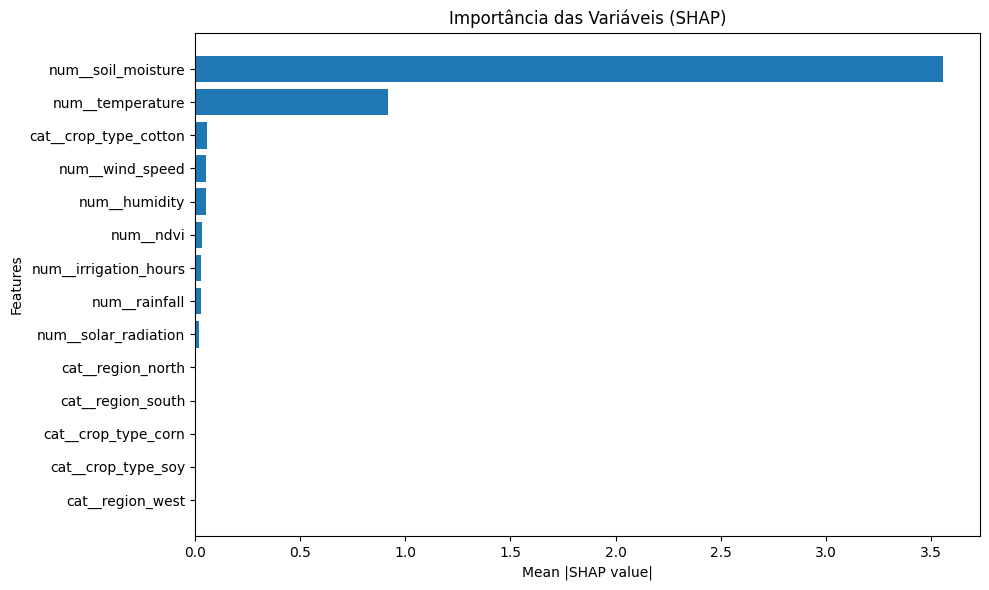

In [17]:
top_n = 15

top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Features")
plt.title("Importância das Variáveis (SHAP)")

plt.tight_layout()
plt.show()

### Explicação individual

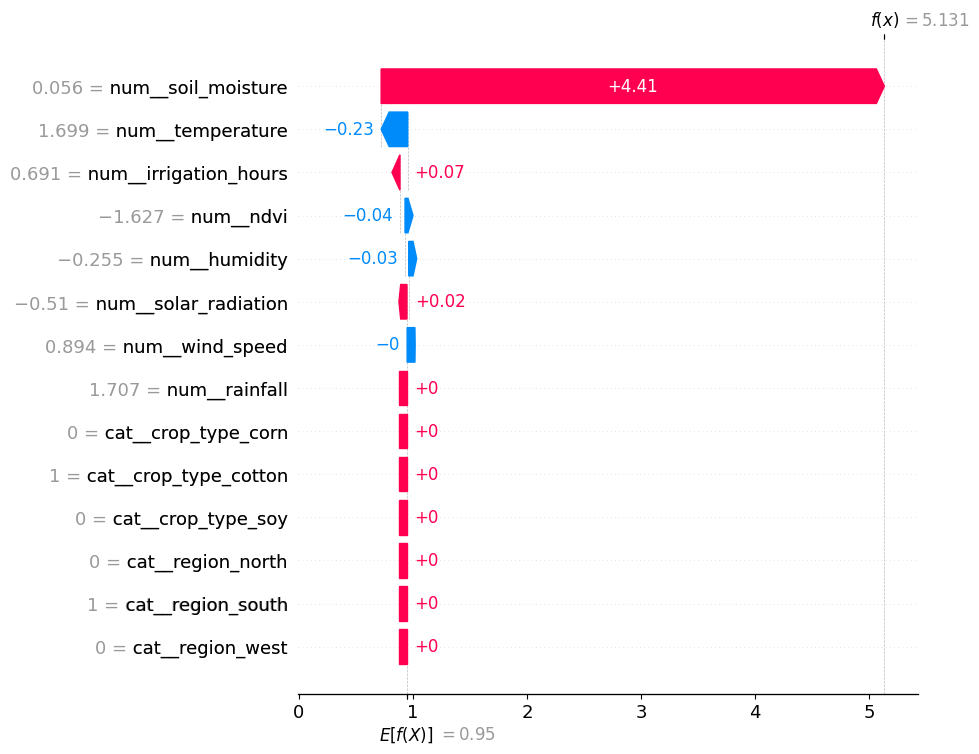

In [18]:
sample_index = 0
class_index = 0  # classe a explicar

shap.plots.waterfall(
    shap_values[sample_index, :, class_index],
    max_display=15
)